In [39]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import os.path as op
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [176]:
def get_best_data(file_list):
    best_mean = -1
    best_data = None

    for f in file_list:
        data = np.load(f, allow_pickle=True).item()
        curr_mean = np.mean(data['accuracy'], axis=0)
        if curr_mean > best_mean:
            best_mean = curr_mean
            best_data = data
    
    return best_data


def get_file_number(file_name):
    match = re.search(r'outputs_(\d+)', file_name)
    return int(match.group(1)) if match else None


def plot_accuracy_curve(ax, data, filename, method_name, n_splits=10, color=None, linewidth=1.5, alpha=0.1, meth_in_label=False):
    """Handles the mean, SEM calculation, and plotting for a single file."""

    accuracy = np.array(data['accuracy'], dtype=float)
    sem = np.array(data['variance'], dtype=float) / np.sqrt(float(n_splits))
    n_PCs = get_file_number(filename)
    x_axis = np.arange(len(accuracy))

    upper, lower = accuracy + sem, accuracy - sem
    if method_name == 'rPCA':
        label = f"{n_PCs} rPCs" if meth_in_label else f"{n_PCs}"
    else:
        label = f"{n_PCs} gcPCs" if meth_in_label else f"{n_PCs}"

    # Plot the main line
    line, = ax.plot(x_axis, accuracy,
                    label=label,
                    color=color, linewidth=linewidth)
    
    # Plot the shaded SEM area
    ax.fill_between(x_axis, lower, upper,
                    color=line.get_color(), alpha=alpha)
    
    return line.get_color()


def get_best_file_info(file_list):
    """Returns both the data and the filename of the best performing file - Based on mean accuracy."""

    if not file_list: return None, None

    best_mean = -1
    best_data = None
    best_file = None

    for file in file_list:
        data = np.load(file, allow_pickle=True).item()
        mean = np.mean(data['accuracy'])
        if mean > best_mean:
            best_mean = mean
            best_data = data
            best_file = file 

    return best_data, best_file


50 file(s) to plot: ['gcPCA_outputs_10_ctx.npy', 'gcPCA_outputs_10_stn.npy', 'gcPCA_outputs_12_ctx.npy', 'gcPCA_outputs_12_stn.npy', 'gcPCA_outputs_14_ctx.npy', 'gcPCA_outputs_14_stn.npy', 'gcPCA_outputs_16_ctx.npy', 'gcPCA_outputs_16_stn.npy', 'gcPCA_outputs_18_ctx.npy', 'gcPCA_outputs_18_stn.npy', 'gcPCA_outputs_20_ctx.npy', 'gcPCA_outputs_20_stn.npy', 'gcPCA_outputs_2_ctx.npy', 'gcPCA_outputs_2_stn.npy', 'gcPCA_outputs_4_ctx.npy', 'gcPCA_outputs_4_stn.npy', 'gcPCA_outputs_6_ctx.npy', 'gcPCA_outputs_6_stn.npy', 'gcPCA_outputs_8_ctx.npy', 'gcPCA_outputs_8_stn.npy', 'rPCA_outputs_10_ctx.npy', 'rPCA_outputs_10_stn.npy', 'rPCA_outputs_12_ctx.npy', 'rPCA_outputs_12_stn.npy', 'rPCA_outputs_14_ctx.npy', 'rPCA_outputs_14_stn.npy', 'rPCA_outputs_16_ctx.npy', 'rPCA_outputs_16_stn.npy', 'rPCA_outputs_18_ctx.npy', 'rPCA_outputs_18_stn.npy', 'rPCA_outputs_1_ctx.npy', 'rPCA_outputs_1_stn.npy', 'rPCA_outputs_20_ctx.npy', 'rPCA_outputs_20_stn.npy', 'rPCA_outputs_2_ctx.npy', 'rPCA_outputs_2_stn.npy',

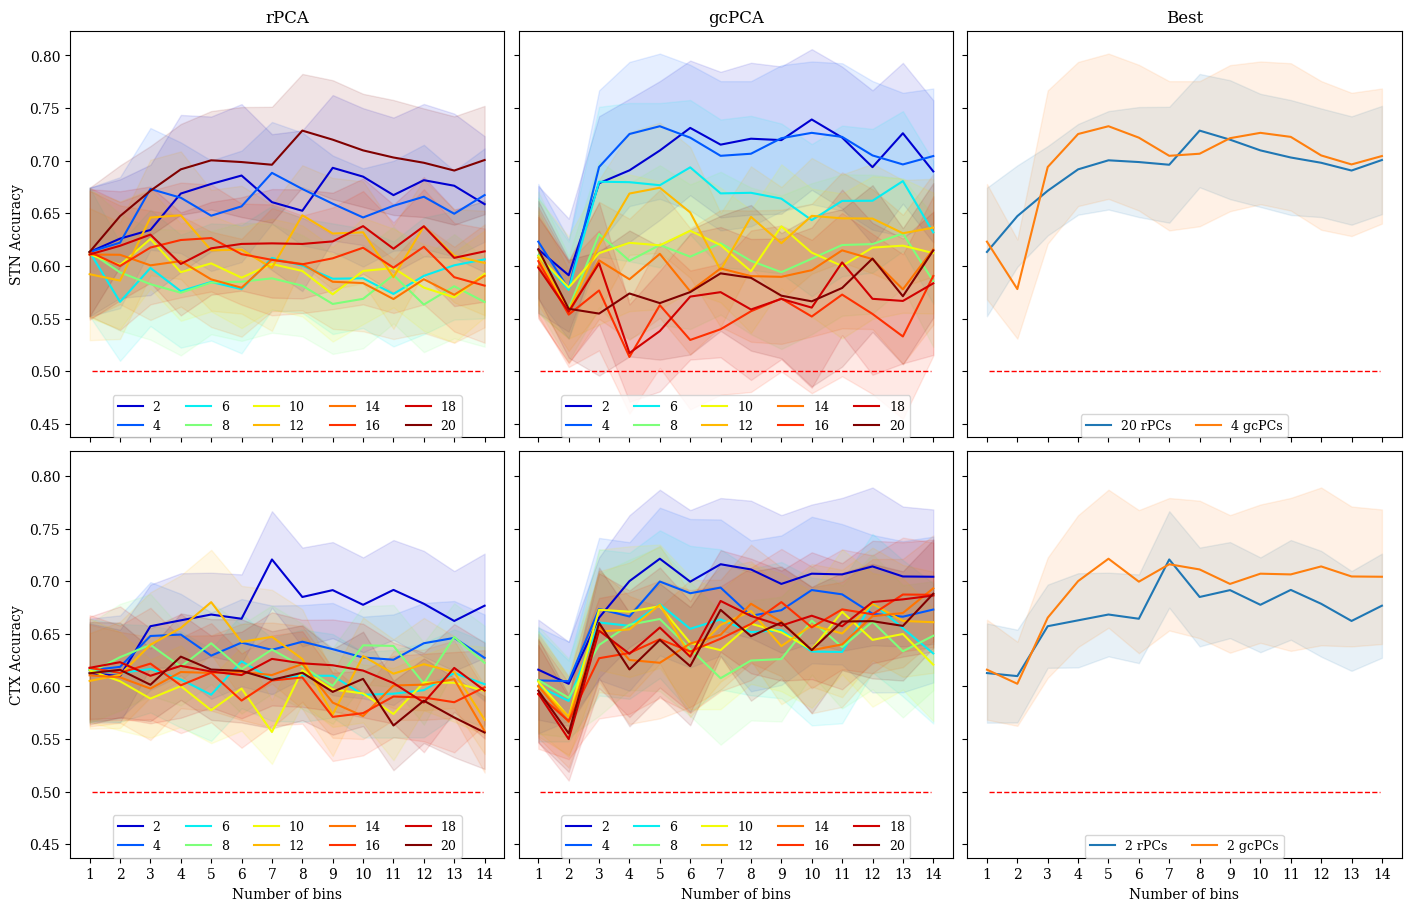

In [231]:
data_to_plot_files = glob.glob(op.join('*PCA_outputs_*.npy'))
print(f"{len(data_to_plot_files)} file(s) to plot: {data_to_plot_files}")

all_n_PCs = sorted(list(set(get_file_number(file) for file in data_to_plot_files)))
colors_pool = plt.cm.jet(np.linspace(0, 1, len(all_n_PCs)))
n_PCs_to_color = dict(zip(all_n_PCs, colors_pool))

n_splits = 10
methods_configuration = {
    'rPCA': {'col': 0, 'label': 'rPCA'},
    'gcPCA': {'col': 1, 'label': 'gcPCA'}
}

best_gcPCA = {}

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True, constrained_layout=True)
areas = ['stn', 'ctx']

for idx_row, area in enumerate(areas):
    best_file = {}  # store the best of each method to plot in the last column

    # Loop through the methods defined in the configuration
    for method_name, config in methods_configuration.items():
        # Filter files for the current method and area
        files = sorted([file for file in data_to_plot_files if method_name in file and area in file])

        if method_name == 'rPCA':
            files = [file for file in files if get_file_number(file) % 2 == 0]

        files.sort(key=get_file_number)  # Sort files based on the number of PCs

        # Plot each file for the current method and area
        for file in files:
            data = np.load(file, allow_pickle=True).item()
            n_PCs = get_file_number(file)

            plot_accuracy_curve(axes[idx_row, config['col']], data, file,
                                n_splits=n_splits, method_name=config['label'],
                                color=n_PCs_to_color[n_PCs],
                                alpha=0.1)

        # Get the best file for the current method and area
        best_file[method_name] = get_best_file_info(files) 

    # Plot the best performing file for each method in the last column
    for method_name, (best_data, best_file_name) in best_file.items():
        if best_file_name is not None:
            n_PCs = get_file_number(best_file_name)
            plot_accuracy_curve(axes[idx_row, 2], best_data, best_file_name,
                                method_name=f"{method_name}",
                                linewidth=1.5, n_splits=n_splits, alpha=0.1,
                                meth_in_label=True)  # color=n_PCs_to_color[n_PCs],
        
        if 'gcPCA' in best_file_name:
            best_gcPCA[area] = (best_data, best_file_name)
            
    # Add the chance-level line and the legend
    for col_idx, ax in enumerate(axes[idx_row, :]):
        ax.axhline(0.5, xmin=0.05, xmax=0.95, color='red', linestyle='--', linewidth=1)
        ax.legend(loc='lower center',
                borderaxespad=0,
                fontsize=9,
                ncols=5)

    axes[idx_row, 0].set_ylabel(f'{area.upper()} Accuracy')

    
col_titles = ['rPCA', 'gcPCA', 'Best']
for i, title in enumerate(col_titles):
    axes[0, i].set_title(f"{title}")

for ax in axes[1, :]:
    ax.set_xlabel('Number of bins')
    ax.set_xticks(range(len(best_data['accuracy'])), labels=[f'{int(x+1)}' for x in np.arange(len(best_data['accuracy']))])

plt.show()

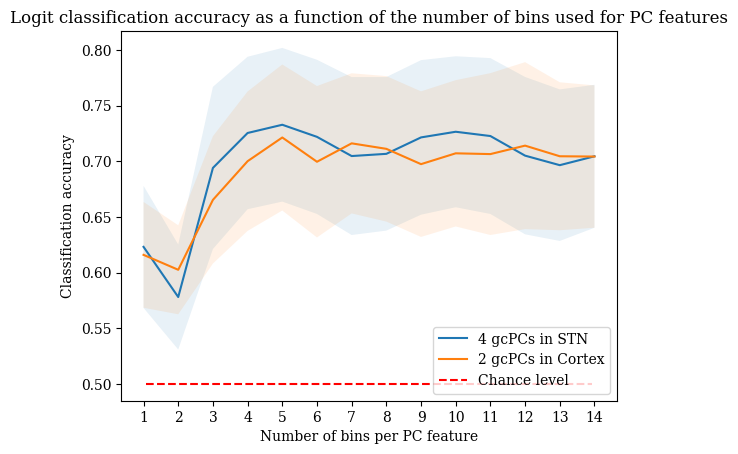

In [230]:
for i, (area, data) in enumerate(best_gcPCA.items()):
    accuracy = np.array(data[0]['accuracy'], dtype=float)
    sem = np.array(data[0]['variance'], dtype=float) / np.sqrt(float(n_splits))
    n_PCs = get_file_number(data[1])
    x_axis = np.arange(len(accuracy))

    upper, lower = accuracy + sem, accuracy - sem
    label = f"{n_PCs} gcPCs in {'STN' if area == "stn" else "Cortex"}"

    # Plot the main line
    line, = plt.plot(x_axis, accuracy,
                    label=label)
    
    # Plot the shaded SEM area
    plt.fill_between(x_axis, lower, upper, alpha=0.1)
plt.axhline(0.5, xmin=0.05, xmax=0.95, color='red', linestyle='--', label='Chance level')
plt.xlabel('Number of bins per PC feature')
plt.xticks(x_axis, labels=[f'{int(x+1)}' for x in x_axis])
plt.ylabel('Classification accuracy')
plt.title('Logit classification accuracy as a function of the number of bins used for PC features')
plt.legend(loc='lower right')  # bbox_to_anchor=(1.02, 0.6)